# Final Project: Topic Modeling

## Executive Summary: 
In 180 to 200 words, provide an overview of the notebooks you developed. Describe the use case, data, preprocessing steps, model development, and main points of the analysis. State which model works best or that none of the models were satisfactory and provide reasons. Describe the topics and explain how the model will address the use case, or if none of the models worked well, state what the next steps should be.

## Importing the Dataset: Trip Advisor Reviews

In [ ]:
import pandas as pd # data manipulation
import langdetect  # language detection
import matplotlib.pyplot  # plotting
import nltk  # natural language processing
import numpy  # arrays and matrices
import pandas  # dataframes
import pyLDAvis  # plotting
import regex  # regular expressions
import sklearn  # machine learning
import unicodedata  # unicode data manipulation
import random # random number generation
import numpy as np # numerical operations

# Text preprocessing and feature extraction
from sklearn.manifold import TSNE  # Required for t-SNE projection
from sklearn.decomposition import NMF  # NMF model
from sklearn.decomposition import LatentDirichletAllocation  # LDA model
from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF vectorizer
from nltk.stem import WordNetLemmatizer  # lemmatizer
from sklearn.feature_extraction.text import CountVectorizer  # Count vectorizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gly3\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gly3\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\gly3\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
# Load the dataset
url = "https://raw.githubusercontent.com/Hunteracademic/Unsupervised_assignment_1/master/tripadvisor_hotel_reviews.csv"
df = pd.read_csv(url)
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


## Preprocessing: 
Clean and prepare text for LDA and NMF topic modeling. Include steps such as case normalization, lemmatization, stop word removal, and tokenization. 

### Language Filter

In [ ]:
# Filter out non-English reviews

# Define a function to identify the language of the text
def do_language_identifying(txt):
    try: the_language = langdetect.detect(txt)
    except: the_language = 'none'
    return the_language

# Apply the language identification function to the 'Review' column and create a new 'Language' column
df['Language'] = df['Review'].apply(do_language_identifying)
print(df['Language'].value_counts())

# Filter the DataFrame to include only English reviews
reviews_en = df[df['Language'] == 'en']

Language
en    20475
fr        6
af        5
nl        2
ro        2
es        1
Name: count, dtype: int64


### Tokenization / Removing Punctuation / Case Normalization

In [ ]:
#  Define a regular expression pattern to match words, including those with apostrophes and hyphens
WORD_RE = regex.compile(r"(?V1)\p{L}+(?:[’'-]\p{L}+)*")

# Define a function to tokenize the text for topic modeling
def tokenize_for_topics(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = regex.sub(r"[‘’`´]", "'", text)      # normalize apostrophes
    text = regex.sub(r"[‐‑‒–—−]", "-", text)    # normalize dash variants
    return WORD_RE.findall(text)

# Apply the tokenization function to the 'Review' column and create a new 'Tokens' column
reviews_en["Tokens"] = reviews_en["Review"].apply(tokenize_for_topics)

# Display the tokens for the first review
reviews_en['Tokens'][0]

['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversary',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'reviews',
 'did',
 'valet',
 'parking',
 'check',
 'quick',
 'easy',
 'little',
 'disappointed',
 'non-existent',
 'view',
 'room',
 'room',
 'clean',
 'nice',
 'size',
 'bed',
 'comfortable',
 'woke',
 'stiff',
 'neck',
 'high',
 'pillows',
 'not',
 'soundproof',
 'like',
 'heard',
 'music',
 'room',
 'night',
 'morning',
 'loud',
 'bangs',
 'doors',
 'opening',
 'closing',
 'hear',
 'people',
 'talking',
 'hallway',
 'maybe',
 'just',
 'noisy',
 'neighbors',
 'aveda',
 'bath',
 'products',
 'nice',
 'did',
 'not',
 'goldfish',
 'stay',
 'nice',
 'touch',
 'taken',
 'advantage',
 'staying',
 'longer',
 'location',
 'great',
 'walking',
 'distance',
 'shopping',
 'overall',
 'nice',
 'experience',
 'having',
 'pay',
 'parking',
 'night']

### Removing Stop Words

In [ ]:
# Remove stop words from the tokens
list_stop_words = nltk.corpus.stopwords.words("English")

# Define a list of additional stop words specific to hotel reviews
hotel_stop_words = ['hotel', 'room', 'stay', 'really', 'just', 'got', 'went', 'also', 'said', 'told', 'day', 'night', 'time', 'week', 'year',
                    'place', 'thing', 'way', 'bit', 'lot', 'little', 'came', 'come', 'went', 'going', 'went', 'away', 'check', 'booked', 'booking', 
                    'trip', 'visit', 'stayed', 'rooms', 'hotels', 'stays']

# Extend the list of stop words with the hotel-specific stop words
list_stop_words.extend(hotel_stop_words)

# Remove stop words from the tokens in the 'Tokens' column
reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [token for token in tokens if token not in list_stop_words])

### Lemmatization

In [ ]:
# Lemmatize the tokens in the 'Tokens' column
lemmatizer = WordNetLemmatizer()
reviews_en['Tokens'] = reviews_en['Tokens'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

# Display the cleaned tokens for the first review
reviews_en['Tokens'].head()

0    [nice, expensive, parking, good, deal, anniver...
1    [ok, nothing, special, charge, diamond, member...
2    [nice, experience, monaco, seattle, good, n't,...
3    [unique, great, wonderful, monaco, location, e...
4    [great, great, seahawk, game, awesome, downfal...
Name: Tokens, dtype: object

## Vectoring the text data:

#### Vectoring for LDA

In [ ]:
# Prepare the data for LDA by joining the tokens back into a single string for each review
LDA_data = reviews_en.copy()
LDA_data['clean_text'] = LDA_data['Tokens'].apply(lambda tokens: ' '.join(tokens))

# Display the cleaned text for the first few reviews
LDA_data[['Tokens', 'clean_text']].head()

,Tokens,clean_text
0,"[nice, expensive, parking, good, deal, anniver...",nice expensive parking good deal anniversary a...
1,"[ok, nothing, special, charge, diamond, member...",ok nothing special charge diamond member hilto...
2,"[nice, experience, monaco, seattle, good, n't,...",nice experience monaco seattle good n't level ...
3,"[unique, great, wonderful, monaco, location, e...",unique great wonderful monaco location excelle...
4,"[great, great, seahawk, game, awesome, downfal...",great great seahawk game awesome downfall view...


In [ ]:
# Define a function to calculate perplexity for different numbers of topics
def perplexity_by_ntopic(data, ntopics, max_df, min_df, max_features):
    """
    Calculate perplexity for different numbers of topics.
    Parameters:
    - data: Document-term matrix (e.g., from CountVectorizer)
    - ntopics: List of numbers of topics to evaluate
    - max_df: Maximum document frequency for term filtering
    - min_df: Minimum document frequency for term filtering
    - max_features: Maximum number of features for term filtering
    Returns:
    - output_df: DataFrame with number of topics and corresponding perplexity scores"""
    
    # Initialize a dictionary to store the number of topics and their corresponding perplexity scores
    output_dict = {
        "Number Of Topics": [], 
        "Perplexity Score": []
    }
    
    # Loop through each number of topics in the ntopics list
    for t in ntopics:
        lda = sklearn.decomposition.LatentDirichletAllocation(
            n_components=t,
            learning_method="batch",
            random_state=0,
            n_jobs=-1
        )

        # Fit the LDA model to the data
        lda.fit(data)
        
        # Append the number of topics and the corresponding perplexity score to the output dictionary
        output_dict["Number Of Topics"].append(t)
        output_dict["Perplexity Score"].append(lda.perplexity(data))

        # Print the current parameter combination and the calculated perplexity score
        print(f"max_df = {max_df}, min_df = {min_df}, max_features = {max_features} : Calculated perplexity for {t} topics: {output_dict['Perplexity Score'][-1]}")

    # Convert the output dictionary to a DataFrame for easier analysis    
    output_df = pandas.DataFrame(output_dict)
    
    # Find the index of the minimum perplexity score and retrieve the corresponding number of topics
    index_min_perplexity = output_df["Perplexity Score"].idxmin()
    output_num_topics = output_df.loc[
        index_min_perplexity,  # index
        "Number Of Topics"  # column
    ]
    
    # Return the DataFrame with perplexity scores and the optimal number of topics     
    return (output_df, output_num_topics)

In [ ]:
# Define different parameter combinations for CountVectorizer
ngram_ranges = [(1, 1), (1, 2)] 
max_dfs = [0.75, 0.85, 0.95]
min_dfs = [2, 5, 10]
max_feats = [1000, 2000, 3000]

count_vectorizers = []

# Loop through everything including the N-Gram range
for n_range in ngram_ranges:
    for max_df in max_dfs:
        for min_df in min_dfs:
            for max_features in max_feats:
                vectorize = CountVectorizer(
                    max_df=max_df,
                    min_df=min_df,
                    max_features=max_features,
                    ngram_range=n_range
                )
                count_vectorizers.append(vectorize)

### Count Vectorizer Grid Search
According to our research and the examples available in the book, we found that the best word vectorizer for LDA models was `CountVectorizer()`. In this step, we explore different values for a count vectorizer to be used for LDA based on perplexity scores as a starting point for our next exploration.

In [ ]:
# Code commented out to avoid long execution time during testing. Uncomment to run the full analysis.

# # Calculate perplexity for each CountVectorizer and store results in a list of DataFrames
# perplexity_dfs = []
# for cv in count_vectorizers:
#     dtm_cv = cv.fit_transform(LDA_data['clean_text'])
    
#     lda_perplexity, optimal_num_topics = perplexity_by_ntopic(
#         dtm_cv,
#         [3, 4, 5, 6],
#         cv.max_df,
#         cv.min_df,
#         cv.max_features
#     )

#     #  Add the label for 1-word or 2-words to the result dataframe
#     label = "1-word" if cv.ngram_range == (1, 1) else "1 & 2-word"
#     lda_perplexity['Ngram_Type'] = label
    
#     lda_perplexity['Max_Features'] = cv.max_features
#     lda_perplexity['Max_DF'] = cv.max_df
#     lda_perplexity['Min_DF'] = cv.min_df
    
#     perplexity_dfs.append(lda_perplexity)

max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 570.8417718003667
max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 4 topics: 572.9017861274805
max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 5 topics: 573.6164136320155
max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 6 topics: 575.4653528518508
max_df = 0.75, min_df = 2, max_features = 2000 : Calculated perplexity for 3 topics: 907.9734320061139
max_df = 0.75, min_df = 2, max_features = 2000 : Calculated perplexity for 4 topics: 893.715861659488
max_df = 0.75, min_df = 2, max_features = 2000 : Calculated perplexity for 5 topics: 894.9277986207072
max_df = 0.75, min_df = 2, max_features = 2000 : Calculated perplexity for 6 topics: 892.8327565458771
max_df = 0.75, min_df = 2, max_features = 3000 : Calculated perplexity for 3 topics: 1127.8028230671441
max_df = 0.75, min_df = 2, max_features = 3000 : Calculated perplexity fo

In [ ]:
# Concatenate all the perplexity DataFrames into a single DataFrame for analysis
perp_concat = pd.concat(perplexity_dfs, ignore_index=True)

# Sort by Perplexity Score (ascending is default, showing lowest/best scores first)
perp_concat.sort_values(by='Perplexity Score', inplace=True)

# Display only the top 10 results
display(perp_concat.head(10))

,Number Of Topics,Perplexity Score,Ngram_Type,Max_Features,Max_DF,Min_DF
0,3,570.841772,1-word,1000,0.75,2
24,3,570.841772,1-word,1000,0.75,10
60,3,570.841772,1-word,1000,0.85,10
36,3,570.841772,1-word,1000,0.85,2
96,3,570.841772,1-word,1000,0.95,10
72,3,570.841772,1-word,1000,0.95,2
12,3,571.312805,1-word,1000,0.75,5
48,3,571.312805,1-word,1000,0.85,5
84,3,571.312805,1-word,1000,0.95,5
87,6,572.002295,1-word,1000,0.95,5


#### Summary of the grid search:

* max_features: Selects the number of most common phrases and builds a matrix whit them. This change results in the biggest perplexity changes (impact in the hundreds).

  Ex:

    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506

    max_df = 0.75, min_df = 2, max_features = 2000 : Calculated perplexity for 3 topics: 940.4003603206078

* ngram_type: Determines whether the model uses only single words or includes two-word phrases. Including bigrams provides much better context for the topics, but it typically results in a moderate increase in the perplexity score (around 10 points)

  Ex:
    
    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 570.8417718003667

    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506

* ntopics = Number of topics the model is splitting the results to. This carries a slight change to the perplexity score (usually in the single digits)

  Ex:

    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506

    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 4 topics: 577.5374308791278


* min_df: Represents the minimum number of documents a word or bi-gram must appear in to be included in your model. This parameter seems to have a very minor change on perplexity usually in the single digits

  Ex:

    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506

    max_df = 0.75, min_df = 5, max_features = 1000 : Calculated perplexity for 3 topics: 584.7858969516453

    max_df = 0.75, min_df = 10, max_features = 1000 : Calculated perplexity for 3 topics: 587.1110544494958


* max_df: Used to filter out words that appear too frequently to be useful for distinguishing between topics. This parameter seems to carry zero weight on the over all perplexity score resulting in no changes

  Ex:

    max_df = 0.75, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506

    max_df = 0.85, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506
    
    max_df = 0.95, min_df = 2, max_features = 1000 : Calculated perplexity for 3 topics: 580.3878297669506


## Models: 
Develop code to first vectorize your text data, and then train at least six LDA and six NMF topic models on these vectors. Use clear section headings for each type of model. Record each set of hyperparameters (for both vectorization and the topic models) that you try, and find the perplexity, word-topic table, and document-topic table for each model. Present this information neatly and use it to select your best LDA and NMF models.

### Defined Approach:
- Performing grid search on different parameters for the vectorizers in order to select the best combination of parameters + an optimal number of topics.
- Once we select our best combination for the vectorizer, we will explore parameter combinations for the models in order to obtain the best combination and select the best model based on that.

### LDA Exploring

### Selecting our number of topics: Helper Function
Function to explore different number of topics

#### LDA Parameters Grid Search (1 word)
We defined the best parameters combination for the count vectorizer definition based on the results above as `cv_final`. This vectorizer is then used to explore different LDA model options.
We are going to store each model using the `max_iter` parameter as the key and the values as the models themselves.

In [ ]:
# Based on the perplexity analysis, we can select the best parameter combination for CountVectorizer and fit the LDA model with different numbers of topics to find the optimal number of topics.
cv_final = CountVectorizer(
    max_df=0.85,        
    min_df=2,          
    max_features=2000,
    ngram_range=(1, 2)
)

# Fit the CountVectorizer to the cleaned text data and transform it into a document-term matrix 
dtm_cv_final = cv_final.fit_transform(LDA_data['clean_text'])

# Define different numbers of topics and maximum iterations for LDA model fitting 
max_iter = [10, 20, 30]
selected_num_topics = [4, 5, 6]
lda_models_arr_sword = {} # Initialize an empty dictionary to store LDA models with max_iter and num_topics as keys

# Loop through each combination of max_iter and num_topics, fit the LDA model, and store the model and its perplexity score in the lda_models_arr_sword dictionary
for iter in max_iter:
    for num_topics in selected_num_topics:
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=0, max_iter=iter, n_jobs=-1)
        lda_model.fit(dtm_cv_final)
        lda_models_arr_sword[(iter, num_topics)] = lda_model
        print(f"Max Iterations: {iter} - Number of Topics: {num_topics} - Perplexity: {lda_model.perplexity(dtm_cv_final)}")

Max Iterations: 10 - Number of Topics: 4 - Perplexity: 934.9471350569152
Max Iterations: 10 - Number of Topics: 5 - Perplexity: 930.483804196706
Max Iterations: 10 - Number of Topics: 6 - Perplexity: 925.6557073275311
Max Iterations: 20 - Number of Topics: 4 - Perplexity: 932.5507364535117
Max Iterations: 20 - Number of Topics: 5 - Perplexity: 927.4491966991687
Max Iterations: 20 - Number of Topics: 6 - Perplexity: 920.5289999711537
Max Iterations: 30 - Number of Topics: 4 - Perplexity: 931.7030670834029
Max Iterations: 30 - Number of Topics: 5 - Perplexity: 926.113945408719
Max Iterations: 30 - Number of Topics: 6 - Perplexity: 919.2329360759007


### LDA Parameters Grid Search (2 words)
We defined the best parameters combination for the count vectorizer definition based on the results above as `cv_final`. This vectorizer is then used to explore different LDA model options.
We are going to store each model using the `max_iter` parameter as the key and the values as the models themselves.

In [ ]:
# Based on the perplexity analysis, we can select the best parameter combination for CountVectorizer and fit the LDA model with different numbers of topics to find the optimal number of topics.
cv_final = CountVectorizer(
    max_df=0.85,        
    min_df=2,          
    max_features=2000,
    ngram_range=(2, 2)
)

# Fit the CountVectorizer to the cleaned text data and transform it into a document-term matrix 
dtm_cv_final = cv_final.fit_transform(LDA_data['clean_text'])

# Define different numbers of topics and maximum iterations for LDA model fitting 
max_iter = [10, 20, 30]
selected_num_topics = [4, 5, 6]
lda_models_arr_mword = {} # Initialize an empty dictionary to store LDA models with max_iter and num_topics as keys

# Loop through each combination of max_iter and num_topics, fit the LDA model, and store the model and its perplexity score in the lda_models_arr_mword dictionary
for iter in max_iter:
    for num_topics in selected_num_topics:
        lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=0, max_iter=iter, n_jobs=-1)
        lda_model.fit(dtm_cv_final)
        lda_models_arr_mword[(iter, num_topics)] = lda_model
        print(f"Max Iterations: {iter} - Number of Topics: {num_topics} - Perplexity: {lda_model.perplexity(dtm_cv_final)}")

Max Iterations: 10 - Number of Topics: 4 - Perplexity: 1267.594083765794
Max Iterations: 10 - Number of Topics: 5 - Perplexity: 1317.3921961235171
Max Iterations: 10 - Number of Topics: 6 - Perplexity: 1330.1851968833353
Max Iterations: 20 - Number of Topics: 4 - Perplexity: 1247.4979485895428
Max Iterations: 20 - Number of Topics: 5 - Perplexity: 1293.1849955032849
Max Iterations: 20 - Number of Topics: 6 - Perplexity: 1291.0274208078877
Max Iterations: 30 - Number of Topics: 4 - Perplexity: 1243.6368913517395
Max Iterations: 30 - Number of Topics: 5 - Perplexity: 1284.5569922494342
Max Iterations: 30 - Number of Topics: 6 - Perplexity: 1283.1817164104834


### Interpretability Check: Words and Document Matrices of models

In [ ]:
# Define a function to extract the top words for each topic and the most relevant documents for each topic from the fitted LDA model
def get_topics(mod, vec, names, docs, ndocs, nwords):
    # word to topic matrix
    W = mod.components_
    W_norm = W / W.sum(axis=1)[:, numpy.newaxis]
    # topic to document matrix
    H = mod.transform(vec)
    
    # Create dictionaries to store the top words and relevant documents for each topic
    W_dict = {}
    H_dict = {}
    
    # Loop through each topic and extract the top words and relevant documents based on the W and H matrices
    for tpc_idx, tpc_val in enumerate(W_norm):
        topic = "Topic{}".format(tpc_idx)
        
        # formatting w
        W_indices = tpc_val.argsort()[::-1][:nwords]
        W_names_values = [
            (round(tpc_val[j], 4), names[j]) 
            for j in W_indices
        ]
        W_dict[topic] = W_names_values
        
        # formatting h
        H_indices = H[:, tpc_idx].argsort()[::-1][:ndocs]
        H_names_values = [
            (round(H[:, tpc_idx][j], 4), docs[j]) 
            for j in H_indices
        ]
        H_dict[topic] = H_names_values

    # Convert the W and H dictionaries into DataFrames for better visualization and analysis    
    W_df = pd.DataFrame(
        W_dict, 
        index=["Word" + str(i) for i in range(nwords)]
    )
    H_df = pd.DataFrame(
        H_dict,
        index=["Doc" + str(i) for i in range(ndocs)]
    )
       
    return (W_df, H_df)

In [ ]:
# Set the number of documents and words to extract for each topic
number_docs = 10 
number_words = 15 

# Extract and Display Single-word (sword) Model Results
# Re-create the vectorizer used for the 'sword' models to ensure feature names match
cv_sword = CountVectorizer(max_df=0.85, min_df=2, max_features=2000, ngram_range=(1, 2))
dtm_sword = cv_sword.fit_transform(LDA_data['clean_text'])

W_df_s, H_df_s = get_topics(
    mod=lda_models_arr_sword[(30, 4)],
    vec=dtm_sword,
    names=cv_sword.get_feature_names_out(),
    docs=LDA_data['Review'].tolist(),
    ndocs=number_docs, 
    nwords=number_words
)

print('=' * 60)
print("RESULTS FOR SINGLE-WORD MODEL (N-GRAM 1,2)")
print('=' * 60)
print("\nWord - Topic Table:")
display(W_df_s) 
print("\nDocument - Topic Table:")
display(H_df_s)


# Extract and Display Multi-word (mword) Model Results
# Re-create the vectorizer used for the 'mword' models
cv_mword = CountVectorizer(max_df=0.85, min_df=2, max_features=2000, ngram_range=(2, 2))
dtm_mword = cv_mword.fit_transform(LDA_data['clean_text'])

W_df_m, H_df_m = get_topics(
    mod=lda_models_arr_mword[(30, 4)],
    vec=dtm_mword,
    names=cv_mword.get_feature_names_out(),
    docs=LDA_data['Review'].tolist(),
    ndocs=number_docs, 
    nwords=number_words
)

print('\n' + '=' * 60)
print("RESULTS FOR MULTI-WORD MODEL (N-GRAM 2,2)")
print('=' * 60)
print("\nWord - Topic Table:")
display(W_df_m) 
print("\nDocument - Topic Table:")
display(H_df_m)

In [ ]:
# Set the number of documents and words to extract for each topic
number_docs = 10 
number_words = 15 

# Extract and Display Single-word (sword) Model Results
# Re-create the vectorizer used for the 'sword' models to ensure feature names match
cv_sword = CountVectorizer(max_df=0.85, min_df=2, max_features=2000, ngram_range=(2, 2))
dtm_sword = cv_sword.fit_transform(LDA_data['clean_text'])

W_df_s, H_df_s = get_topics(
    mod=lda_models_arr_sword[(30, 4)],
    vec=dtm_sword,
    names=cv_sword.get_feature_names_out(),
    docs=LDA_data['Review'].tolist(),
    ndocs=number_docs, 
    nwords=number_words
)

print('=' * 60)
print("RESULTS FOR SINGLE-WORD MODEL (N-GRAM 2,2)")
print('=' * 60)
print("\nWord - Topic Table:")
display(W_df_s) 
print("\nDocument - Topic Table:")
display(H_df_s)


# Extract and Display Multi-word (mword) Model Results
# Re-create the vectorizer used for the 'mword' models
cv_mword = CountVectorizer(max_df=0.85, min_df=2, max_features=2000, ngram_range=(2, 2))
dtm_mword = cv_mword.fit_transform(LDA_data['clean_text'])

W_df_m, H_df_m = get_topics(
    mod=lda_models_arr_mword[(30, 4)],
    vec=dtm_mword,
    names=cv_mword.get_feature_names_out(),
    docs=LDA_data['Review'].tolist(),
    ndocs=number_docs, 
    nwords=number_words
)

print('\n' + '=' * 60)
print("RESULTS FOR MULTI-WORD MODEL (N-GRAM 2,2)")
print('=' * 60)
print("\nWord - Topic Table:")
display(W_df_m) 
print("\nDocument - Topic Table:")
display(H_df_m)

RESULTS FOR SINGLE-WORD MODEL (N-GRAM 2,2)

Word - Topic Table:


,Topic0,Topic1,Topic2,Topic3
Word0,"(0.0216, good review)","(0.0217, beach pool)","(0.0226, good review)","(0.0111, beautiful food)"
Word1,"(0.0201, large group)","(0.0195, reasonable price)","(0.0148, michael jackson)","(0.0097, dinner beach)"
Word2,"(0.0179, small fridge)","(0.0158, french quarter)","(0.0132, right corner)","(0.0082, right corner)"
Word3,"(0.0178, good food)","(0.0147, partial ocean)","(0.0107, view ocean)","(0.0081, kid club)"
Word4,"(0.0156, best view)","(0.013, good review)","(0.0104, small fridge)","(0.0072, small fridge)"
Word5,"(0.0124, champ elysees)","(0.0127, good food)","(0.0099, large group)","(0.0069, free mini)"
Word6,"(0.0098, great lot)","(0.0102, reception area)","(0.0093, reception area)","(0.0067, beach good)"
Word7,"(0.0095, walk beach)","(0.009, ok good)","(0.0091, bad service)","(0.0063, easy reach)"
Word8,"(0.0093, friendly service)","(0.0078, small fridge)","(0.0085, good food)","(0.0058, saona island)"
Word9,"(0.0092, family friendly)","(0.0075, michael jackson)","(0.0074, breakfast quite)","(0.0056, pleasant helpful)"



Document - Topic Table:


,Topic0,Topic1,Topic2,Topic3
Doc0,"(0.9496, excellent stay stayed hotel 1-4. new ...","(0.967, 5 star review montecarlo, booked hotel...","(0.9627, good second time stayed, time 2 years...","(0.9549, nice place great location, pleasantly..."
Doc1,"(0.9481, great haven husband king room floor 6...","(0.9658, hong kong grande dame grand hong kong...","(0.9522, great place want chime reinforce good...","(0.9533, brilliant, wow, went new york end apr..."
Doc2,"(0.9469, heart stayed celebrate 20th wedding a...","(0.9598, mixed review older hotel not enamored...","(0.9496, pretty good pre-christmas visit night...","(0.9494, perfect week, women family decided go..."
Doc3,"(0.946, big rooms good service noisy stayed ni...","(0.9577, terrible vacation vacationed use term...","(0.948, oasis delight stayed boyfriend hotel 3...","(0.9488, wonderful hotel great staff decided s..."
Doc4,"(0.943, 5 star service attitude family 5 3 sma...","(0.9577, wonderful hotel, stayed 2 nights leav...","(0.947, nice time overall husband mini-vacatio...","(0.9457, nice room improvement wife just retur..."
Doc5,"(0.9423, horrific n't, stayed excellence punta...","(0.956, lovely hotel great staff good minor co...","(0.9468, nice hotel inter-continental san juan...","(0.9456, great hotel great location not wait n..."
Doc6,"(0.942, beautiful property, teenage daughter s...","(0.9555, nice great service nice higher end ho...","(0.9462, great location spent 7 days castle in...","(0.9442, great, kids loved loved, stayed 2 nig..."
Doc7,"(0.9387, loved affina dumont stayed nights sep...","(0.955, disappointing husband stayed 3 nights ...","(0.9458, pleasant stay pleasant stay el san ju...","(0.9425, great hotel husband just spent 3 nigh..."
Doc8,"(0.9387, persistence pays, stayed barcelo domi...","(0.9546, great time riu bambu, husband stayed ...","(0.9449, not bad business trip food, hotel n't...","(0.9423, loved took quick trip mr. night,12/29..."
Doc9,"(0.9375, n't better location just got writing ...","(0.9529, best vacation used local travel agent...","(0.9448, majestic great booked majestic honeym...","(0.9411, nogo soho not kind person normally co..."



RESULTS FOR MULTI-WORD MODEL (N-GRAM 2,2)

Word - Topic Table:


,Topic0,Topic1,Topic2,Topic3
Word0,"(0.0243, punta cana)","(0.0154, check in)","(0.0196, san juan)","(0.0237, great location)"
Word1,"(0.0108, food good)","(0.0096, hong kong)","(0.0167, th floor)","(0.0223, minute walk)"
Word2,"(0.0079, pool beach)","(0.0092, internet access)","(0.0165, new york)","(0.0201, staff friendly)"
Word3,"(0.0073, la carte)","(0.0086, flat screen)","(0.0134, great location)","(0.015, friendly helpful)"
Word4,"(0.0072, beach pool)","(0.0083, customer service)","(0.0122, san francisco)","(0.0138, walking distance)"
Word5,"(0.0068, make sure)","(0.0078, screen tv)","(0.0117, great view)","(0.0128, staff helpful)"
Word6,"(0.0059, pool bar)","(0.0076, non smoking)","(0.0113, walking distance)","(0.0101, good value)"
Word7,"(0.0058, pool area)","(0.0071, desk staff)","(0.01, highly recommend)","(0.0096, value money)"
Word8,"(0.0056, beach beautiful)","(0.007, air conditioning)","(0.0098, staff friendly)","(0.0091, train station)"
Word9,"(0.0051, staff friendly)","(0.0067, size bed)","(0.0097, time square)","(0.0089, location great)"



Document - Topic Table:


,Topic0,Topic1,Topic2,Topic3
Doc0,"(0.9907, got paid dr/melia caribe tropical, le...","(0.9699, probably wont stay email sent vagabon...","(0.9741, absolutely loved san juan marriott, r...","(0.9754, average reasonably priced hotel delle..."
Doc1,"(0.9899, ca n't wait till year, 2nd 16th 2008w...","(0.9692, not worthy doubletree relatively minu...","(0.9734, sheraton location tough beat sheraton...","(0.9745, good hotel great location good hotel ..."
Doc2,"(0.9895, absolutely amazing, resort absolutely...","(0.9685, excellant experience harrah stay harr...","(0.9665, great property great stay just return...","(0.9733, bloomin great just returned 3 night c..."
Doc3,"(0.9894, n't, travel agent immediately, i__Ç_é...","(0.9661, good starting point ruined lack servi...","(0.9663, little gem busy union square having d...","(0.9714, beautiful city perfect location just ..."
Doc4,"(0.9892, nice family vacation just returned we...","(0.9659, work progress hotel jen definitely re...","(0.9658, great family vacation new orleans enj...","(0.9707, excellent hotel fantastic location, s..."
Doc5,"(0.989, really enjoying gppc group 9 friends a...","(0.963, good not flawless stayed langham place...","(0.9648, ditto great reviews, repeat previous ...","(0.9693, excellent location 1/2 block placa ca..."
Doc6,"(0.9883, great 6 apple square deal wife early ...","(0.962, not fans, reserved room mandarin orien...","(0.9626, truly special place, ok pay nose stay...","(0.9693, absolutely fantastic stayed hotel wee..."
Doc7,"(0.9882, incredibly majestic couple mid 20s tr...","(0.9611, avoid costs stayed 1 week october 200...","(0.9613, affinia 50 great hotel friend stayed ...","(0.9691, good hotel good location recently sta..."
Doc8,"(0.9881, grand paradise know, left home did re...","(0.9602, extremely overrated, n't fooled partn...","(0.9604, best 100 hotel, positive reviews trip...","(0.9691, great hotel boyfriend stayed hotel ca..."
Doc9,"(0.988, 6/1/06 6/7/06 great time n't, ok think...","(0.9601, great deal money doing alot research ...","(0.9597, exceptional experience intercontinent...","(0.9688, stylish hotel great location good cle..."


In [ ]:
# Extract and Display Multi-word (mword) Model Results
# Re-create the vectorizer used for the 'mword' models
cv_mword = CountVectorizer(max_df=0.85, min_df=2, max_features=2000, ngram_range=(2, 2))
dtm_mword = cv_mword.fit_transform(LDA_data['clean_text'])

W_df_m, H_df_m = get_topics(
    mod=lda_models_arr_mword[(30, 5)],
    vec=dtm_mword,
    names=cv_mword.get_feature_names_out(),
    docs=LDA_data['Review'].tolist(),
    ndocs=number_docs, 
    nwords=number_words
)

print('\n' + '=' * 60)
print("RESULTS FOR MULTI-WORD MODEL (N-GRAM 2,2)")
print('=' * 60)
print("\nWord - Topic Table:")
display(W_df_m) 
print("\nDocument - Topic Table:")
display(H_df_m)


RESULTS FOR MULTI-WORD MODEL (N-GRAM 2,2)

Word - Topic Table:


,Topic0,Topic1,Topic2,Topic3,Topic4
Word0,"(0.0265, punta cana)","(0.0146, internet access)","(0.0234, great location)","(0.0255, minute walk)","(0.0338, san juan)"
Word1,"(0.0106, food good)","(0.012, free internet)","(0.0183, th floor)","(0.0221, great location)","(0.0169, hong kong)"
Word2,"(0.0079, la carte)","(0.0103, good location)","(0.0143, walking distance)","(0.0217, staff friendly)","(0.0161, pool area)"
Word3,"(0.0078, pool beach)","(0.0103, air conditioning)","(0.0136, san francisco)","(0.0168, friendly helpful)","(0.0148, check in)"
Word4,"(0.0075, beach pool)","(0.0097, flat screen)","(0.0123, location great)","(0.0139, staff helpful)","(0.0142, old san)"
Word5,"(0.0072, make sure)","(0.0088, screen tv)","(0.0113, new orleans)","(0.0128, walking distance)","(0.0129, puerto rico)"
Word6,"(0.0063, pool bar)","(0.0086, non smoking)","(0.0112, highly recommend)","(0.0114, new york)","(0.0118, ocean view)"
Word7,"(0.0062, beach beautiful)","(0.0086, check in)","(0.0104, staff friendly)","(0.0106, train station)","(0.011, customer service)"
Word8,"(0.0052, staff friendly)","(0.0085, double bed)","(0.0089, great view)","(0.0098, value money)","(0.0096, credit card)"
Word9,"(0.005, speak english)","(0.0077, size bed)","(0.0085, union square)","(0.0094, min walk)","(0.0077, ritz carlton)"



Document - Topic Table:


,Topic0,Topic1,Topic2,Topic3,Topic4
Doc0,"(0.9902, got paid dr/melia caribe tropical, le...","(0.9752, pros cons st. vincent guesthouse read...","(0.9648, little gem busy union square having d...","(0.9709, beautiful city perfect location just ...","(0.9736, great time westin rio mar, know like ..."
Doc1,"(0.9894, ca n't wait till year, 2nd 16th 2008w...","(0.9646, good value hotel 3-star 4-star genera...","(0.9647, great family vacation new orleans enj...","(0.9695, favourite pick places stayed europe, ...","(0.9728, okay not luxury just got 3 nights/4 d..."
Doc2,"(0.9891, absolutely amazing, resort absolutely...","(0.9605, excellent first-time experience winga...","(0.9641, wonderful place stay stayed orchard w...","(0.969, excellent hotel fantastic location, st...","(0.9686, dorado del mar decent spent week dora..."
Doc3,"(0.989, ocean blue excellent resort, boyfriend...","(0.9595, good hotel complicated internet acces...","(0.9613, nice reasonably priced wife stayed gr...","(0.9688, 40th birthday surprise, say, trip pla...","(0.9673, bad reviews worried sister returned p..."
Doc4,"(0.989, sirenis cocotal beach resort wonderful...","(0.959, not 5* grand luxe arrived claris frida...","(0.9595, great little place stay booked night ...","(0.9677, absolutely fantastic stayed hotel wee...","(0.9672, nice pricey, preferred time san juan ..."
Doc5,"(0.9889, n't, travel agent immediately, i__Ç_é...","(0.9574, good star beware smoking rooms booked...","(0.9564, hidden treasure, seasons san francisc...","(0.9676, good hotel good location recently sta...","(0.966, worked, suggest renting car, starters ..."
Doc6,"(0.9887, nice family vacation just returned we...","(0.9572, good centrally located stayed charles...","(0.955, great room location service price rece...","(0.9676, excellent location 1/2 block placa ca...","(0.965, horrendous service wife stayed normand..."
Doc7,"(0.9882, great 6 apple square deal wife early ...","(0.9548, good room nice staff closer downtown ...","(0.9545, great new orleans travel agent stay h...","(0.9675, convenient clean husband stayed hotel...","(0.9632, pleasant stayed caribe hilton nights ..."
Doc8,"(0.9879, great weather time secrets husband co...","(0.9543, probably ca n't wrong, hotel welcome ...","(0.9544, best location stayed hyatt october 5 ...","(0.9664, excellent hotel modern clean helpful ...","(0.963, isla verde port reeko family 5 stayed ..."
Doc9,"(0.9877, great vacation kids, relaxing vacatio...","(0.9541, terrrible reception staff good locati...","(0.9541, adagio- fantastic not happier 4 day s...","(0.9662, good mid-range hotel great staff prep...","(0.9629, wonderful resort hotel best hotel san..."


### Summary

After running all the grid searches our conclusion is:

When it comes to 1 word vs 2 word models even though 2 words greatly increase the perplexity score, we decided to go with 2 words as it makes it easier to identify and define the topic with more context

For topics we noticed with more topics the distinction between them becomes smaller making it hard to define them. For this reason we choose to stick with 4 topics

For max features we decided that 1000 is also not a great option due to the limited pool of phrases that we have to work with, resulting in too much overlap/similarities 

Min DF increases the perplexity score so we decided to keep it low

Max DF carries no impact so we choose the middle ground and stuck with 0.85

Model Chosen: ngram_range (2,2), max_df = 0.85, min_df = 2, max_features = 2000 : Calculated perplexity for 4 topics: 934.9471350569152

In [ ]:
# --- Data Preparation ---
neg_neutral = reviews_en[reviews_en['Rating'] <= 3]
positive = reviews_en[reviews_en['Rating'] > 3]
positive_sampled = positive.sample(n=len(neg_neutral), random_state=42)
balanced_df = pd.concat([neg_neutral, positive_sampled]).reset_index(drop=True)
balanced_df['clean_text'] = balanced_df['Tokens'].apply(lambda tokens: ' '.join(tokens))

# --- Vectorization & Modeling (Bi-grams, K=4) ---
bi_cv = CountVectorizer(max_df=0.85, min_df=5, max_features=2000, ngram_range=(2, 2))
dtm_bi = bi_cv.fit_transform(balanced_df['clean_text'])

final_lda_bi = LatentDirichletAllocation(n_components=4, random_state=42, n_jobs=-1)
final_lda_bi.fit(dtm_bi)

# --- Manual Data Extraction for Visualizer ---
def format_data_for_vis(model, dtm, vectorizer):
    return {
        'topic_term_dists': model.components_ / model.components_.sum(axis=1)[:, np.newaxis],
        'doc_topic_dists': model.transform(dtm),
        'doc_lengths': dtm.sum(axis=1).getA1(),
        'vocab': vectorizer.get_feature_names_out(),
        'term_frequency': dtm.sum(axis=0).getA1()
    }

data = format_data_for_vis(final_lda_bi, dtm_bi, bi_cv)

# --- Visualization with t-SNE ---
# We define a lambda to ensure pyLDAvis uses the sklearn TSNE implementation properly
lda_display = pyLDAvis.prepare(
    **data, 
    sort_topics=False, 
    mds=lambda dists: TSNE(n_components=2, perplexity=2, random_state=42, init='pca').fit_transform(dists)
)

pyLDAvis.display(lda_display)

In [ ]:
# The matrix 'dtm_bi' has 10,786 rows (from balanced_df)
lda_bi_topic_results = final_lda_bi.transform(dtm_bi)

# FIX: Assign the topics to balanced_df, not LDA_data
balanced_df['Topic'] = lda_bi_topic_results.argmax(axis=1)

# Reorder columns using balanced_df
balanced_results = balanced_df[['Review', 'Rating', 'Topic', 'Tokens']]

# See the average rating for each topic
print("Average Rating per Topic:")
print(balanced_results.groupby('Topic')['Rating'].mean())

# See how many reviews fell into each topic
print("\nReview Count per Topic:")
print(balanced_results['Topic'].value_counts())

Average Rating per Topic:
Topic
0    2.290198
1    3.876588
2    3.596452
3    3.199825
Name: Rating, dtype: float64

Review Count per Topic:
Topic
1    4173
3    2287
2    2255
0    2071
Name: count, dtype: int64


#### Abstract Topics Found by the best LDA model
##### Topic 1: Complaints & Front Desk Interactions - Avg Rating (2.29)
Topic 1 is distinctly complaints and bad reviews. Its top terms include "check in," "customer service," "credit card," "desk staff," "called desk," "desk clerk," "check out," "staff rude," "travel agent," and "star rating." The prominence of front desk terminology ("desk staff," "desk clerk," "called desk") alongside negative signals like "staff rude," "needless say," and "looked like" suggests these are reviews where guests encountered problems — often during arrival/departure or with room assignments ("double bed," "single bed," "king bed," "size bed").
##### Topic 2: Good Hotels in General (Good location/Great Value) Reviews - Avg Rating (3.87)
This topic has the best rating so far on average. It includes words like "train station", "value money", "staff friendly", "minute walk" and "good location" as well as having the highest star rating indicate that this hotel type is nice, in a good geographic location and worth your money.
Topic 2 is much broader and destination-agnostic. Its top terms revolve around staff behavior and hotel amenities: "staff friendly," "friendly helpful," "staff helpful," "bed comfortable," "breakfast included," "air conditioning," "mini bar," "internet access," and "free internet." Location still appears ("great location," "minute walk," "walking distance"), but it's framed generically rather than tied to any specific city or landmark.
##### Topic 3: Location & Destination Identity - Avg Rating (3.59)
Topic 3 is strongly anchored around specific geographic destinations. Its top terms include "san juan," "new orleans," "san francisco," "hong kong," "french quarter," "cable car," "union square," and "puerto rico"; these are all iconic city landmarks or neighborhoods. Reviewers in this topic seem to be praising hotels primarily in the context of where they are situated relative to must-see local attractions, suggesting the destination itself is a major part of the appeal.
##### Topic 4: Resorts/All-inclusive stays - Avg Rating (3.19)
Topic 4 is the largest topic by token share and is overwhelmingly centered on Caribbean/tropical all-inclusive resorts. The dominant term "punta cana" appears with a dramatically higher estimated frequency than any other term in the entire model, and it's reinforced by "dominican republic," "all inclusive," "pool beach," "beach pool," "pool bar," "swim bar," "la carte," "carte restaurant," and "bottled water" — all hallmarks of the all-inclusive resort experience. This topic is the most geographically specific of all four, essentially dedicated to a single resort destination type.
 

### LDA Visualizations: T-SNE

In [ ]:
# Updated function to handle the new parameter naming convention
def plot_tsne(data, threshold, perplexity=30, n_iter=1000):
    # filter data according to threshold
    index_meet_threshold = numpy.amax(data, axis=1) >= threshold
    lda_transform_filt = data[index_meet_threshold]
   
    # fit tsne model
    # FIX: Changed n_iter to max_iter
    tsne = sklearn.manifold.TSNE(
        n_components=2,
        verbose=0,
        random_state=0,
        angle=0.5,
        init='pca',
        perplexity=perplexity,
        max_iter=n_iter # Renamed this keyword argument
    )
    tsne_fit = tsne.fit_transform(lda_transform_filt)
   
    # rest of the function remains the same...
    most_prob_topic = []
    for i in range(tsne_fit.shape[0]):
        most_prob_topic.append(lda_transform_filt[i].argmax())
   
    print("LENGTH:\n{}\n".format(len(most_prob_topic)))
 
    unique, counts = numpy.unique(
        numpy.array(most_prob_topic),
        return_counts=True
    )
 
    print("COUNTS:\n{}\n".format(numpy.asarray((unique, counts)).T))
   
    # make plot
    color_list = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
 
    for i in list(set(most_prob_topic)):
        indices = [idx for idx, val in enumerate(most_prob_topic) if val == i]
        matplotlib.pyplot.scatter(
            x=tsne_fit[indices, 0],
            y=tsne_fit[indices, 1],
            s=0.5,
            c=color_list[i],
            label='Topic' + str(i),
            alpha=0.25
        )
 
    matplotlib.pyplot.xlabel('x-tsne')
    matplotlib.pyplot.ylabel('y-tsne')
    matplotlib.pyplot.legend(markerscale=10)

LENGTH:
5439

COUNTS:
[[   0  675]
 [   1 2316]
 [   2  960]
 [   3 1488]]



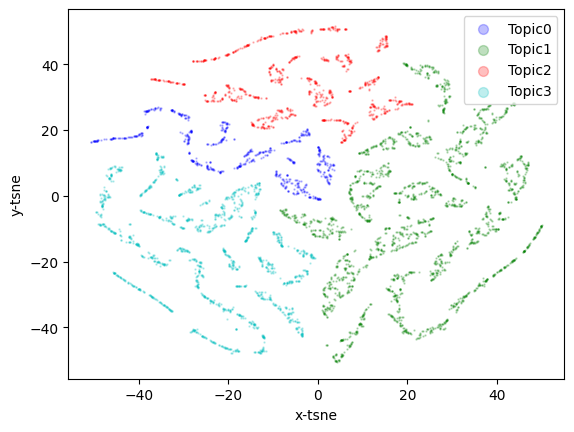

In [ ]:
plot_tsne(data=lda_bi_topic_results, threshold=0.75, perplexity=15, n_iter=500)

## Modeling NMF
### Vectorization for NMF

In [ ]:
# Create a dedicated NMF dataframe from your english reviews
nmf_data = reviews_en.copy()

# Ensure the clean_text column exists (joining the lemmatized tokens)
nmf_data['clean_text'] = nmf_data['Tokens'].apply(lambda tokens: ' '.join(tokens))

# Preview the clean data
nmf_data[['Review', 'clean_text']].head()

,Review,clean_text
0,nice hotel expensive parking got good deal sta...,nice expensive parking good deal anniversary a...
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,nice experience monaco seattle good n't level ...
3,"unique, great stay, wonderful time hotel monac...",unique great wonderful monaco location excelle...
4,"great stay great stay, went seahawk game aweso...",great great seahawk game awesome downfall view...


In [ ]:
def nmf_reconstruction_error(data, ntopics, max_df, min_df, max_features):  # function to calculate reconstruction error for NMF model with different numbers of topics and vectorizer parameters
    nmf_output_dict = {
        "Number Of Topics": [], 
        "Reconstruction Error": []
    }
    
    for t in ntopics:   # iterate over the list of topic numbers
        nmf = sklearn.decomposition.NMF(
            n_components=t,
            solver='cd',
            random_state=0
        )
        nmf.fit(data)
        
        nmf_output_dict["Number Of Topics"].append(t)
        nmf_output_dict["Reconstruction Error"].append(nmf.reconstruction_err_)
        print(f"max_df = {max_df}, min_df = {min_df}, max_features = {max_features} : Calculated reconstruction error for {t} topics: {nmf_output_dict['Reconstruction Error'][-1]}")
        
    output_df = pandas.DataFrame(nmf_output_dict)   # convert the output dictionary to a pandas dataframe for easier analysis
    
    index_min_perplexity = output_df["Reconstruction Error"].idxmin()   # get the index of the minimum reconstruction error
    output_num_topics = output_df.loc[
        index_min_perplexity,
        "Number Of Topics"
    ]
        
    return (output_df, output_num_topics)

### NMF Grid Search

In [ ]:
tfidf_number_docs = 10
tfidf_number_words = 10

tfidf_max_dfs = [0.85]
tfidf_min_dfs = [2, 5, 10]
tfidf_max_feats = [2000, 3000, 5000]

tfidf_vectorizers = [] 
for max_df in tfidf_max_dfs:
    for min_df in tfidf_min_dfs:
        for max_features in tfidf_max_feats:
            tfidf_vectorizer = TfidfVectorizer(
                max_df=max_df,
                min_df=min_df,
                max_features=max_features,
                stop_words=hotel_stop_words,
                ngram_range=(2, 2)
            )
            tfidf_vectorizers.append(tfidf_vectorizer)

In [ ]:
import warnings
warnings.filterwarnings("ignore")
tfidf_perplexity_dfs = []
for tfidf_v in tfidf_vectorizers:
    dtm_cv = tfidf_v.fit_transform(nmf_data['clean_text'])

    nmf_perplexity, optimal_num_topics = nmf_reconstruction_error(
        dtm_cv,
        [3, 4, 5, 6],
        tfidf_v.max_df,
        tfidf_v.min_df,
        tfidf_v.max_features
    )

    nmf_perplexity['Max_Features'] = tfidf_v.max_features
    nmf_perplexity['Max_DF'] = tfidf_v.max_df
    nmf_perplexity['Min_DF'] = tfidf_v.min_df
    tfidf_perplexity_dfs.append(nmf_perplexity)

max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 3 topics: 140.8219332883168
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 4 topics: 140.4881730529801
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 5 topics: 140.17601109487987
max_df = 0.85, min_df = 2, max_features = 2000 : Calculated reconstruction error for 6 topics: 139.92866689729826
max_df = 0.85, min_df = 2, max_features = 3000 : Calculated reconstruction error for 3 topics: 141.35043330412998
max_df = 0.85, min_df = 2, max_features = 3000 : Calculated reconstruction error for 4 topics: 141.08759105473294
max_df = 0.85, min_df = 2, max_features = 3000 : Calculated reconstruction error for 5 topics: 140.81433481681947
max_df = 0.85, min_df = 2, max_features = 3000 : Calculated reconstruction error for 6 topics: 140.60755433411174
max_df = 0.85, min_df = 2, max_features = 5000 : Calculated reconstruction error for 3 top

### Selecting our Best NMF
NMF reconstruction error measures how well the two factored matrices W (document-topic) and H (topic-term) multiply back to approximate your original document-term matrix V. In short: lower error = better approximation = less information lost. When we run a grid search we find no meaningful differences in the resulting reconstruction error. Because of this we decided to choose the NMF model with hyperparameters that most closely reflect our LDA model.
 

LENGTH:
20473

COUNTS:
[[    0 10568]
 [    1  6851]
 [    2  2438]
 [    3   616]]



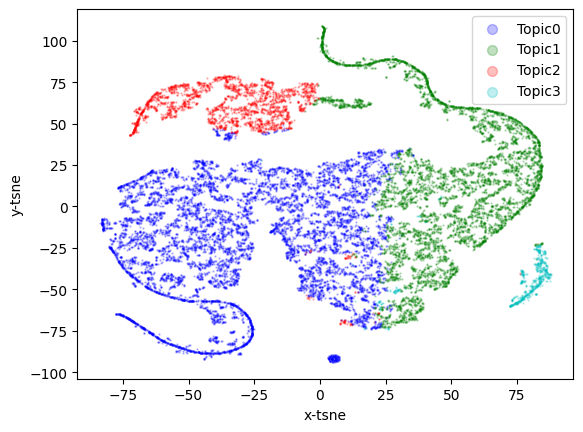

In [ ]:

nmf = sklearn.decomposition.NMF(
    n_components=4,
    solver='cd',
    random_state=0,
)

nmf_transformed = nmf.fit_transform(tfidf_vectorizers[1].fit_transform(nmf_data['clean_text']))

plot_tsne(data=nmf_transformed, threshold=0)

In [ ]:
wdf, hdf, = get_topics(
    mod=nmf, 
    vec=tfidf_vectorizers[1].fit_transform(nmf_data['clean_text']), # fit_transform the clean text data using the first TF-IDF vectorizer
    names=tfidf_vectorizers[1].get_feature_names_out(), 
    docs=nmf_data['Review'].tolist(), 
    ndocs=tfidf_number_docs, 
    nwords=tfidf_number_words
)

In [ ]:
display(wdf)

,Topic0,Topic1,Topic2,Topic3
Word0,"(0.0237, great location)","(0.0207, punta cana)","(0.0833, staff friendly)","(0.1129, san juan)"
Word1,"(0.0093, staff helpful)","(0.0061, food good)","(0.0642, friendly helpful)","(0.0545, old san)"
Word2,"(0.0092, walking distance)","(0.0054, make sure)","(0.0091, clean staff)","(0.0266, puerto rico)"
Word3,"(0.0087, minute walk)","(0.0048, la carte)","(0.0055, new york)","(0.0161, el san)"
Word4,"(0.0086, location great)","(0.0048, pool beach)","(0.005, helpful staff)","(0.0105, pool area)"
Word5,"(0.0061, th floor)","(0.0044, beach pool)","(0.0047, minute walk)","(0.0103, isla verde)"
Word6,"(0.0058, good value)","(0.004, beach beautiful)","(0.0041, good location)","(0.006, ocean view)"
Word7,"(0.0053, value money)","(0.0034, pool bar)","(0.004, bed comfortable)","(0.0055, ritz carlton)"
Word8,"(0.0049, good location)","(0.0032, pool area)","(0.004, clean comfortable)","(0.0054, el yunque)"
Word9,"(0.0046, train station)","(0.0031, carte restaurant)","(0.0032, helpful clean)","(0.005, rent car)"


In [ ]:
display(hdf)  

,Topic0,Topic1,Topic2,Topic3
Doc0,"(0.1356, beautiful hotel, beautiful hotel just...","(0.21, punta cana spent 7 amazing days hotel, ...","(0.3211, relaxed hortus stop long journey, roo...","(0.2933, quiet getaway fajardo inn real quiet ..."
Doc1,"(0.1356, fantastic hotel gorgeous hotel great ...","(0.21, dissapointing hotel punta cana general ...","(0.3211, fab hotel, wow, amazing hotel, stayed...","(0.2933, worst hotel san juan stayed mid-decem..."
Doc2,"(0.1356, love stay loved hotel stayed family, ...","(0.21, dreams punta cana entertainment enterta...","(0.3211, staff no respect sleeping guests staf...","(0.2815, nice urban resort just returned four-..."
Doc3,"(0.1356, perfect, impressive place, want clean...","(0.21, diarrhea punta cana bring diarrhea medi...","(0.3211, problem komaneka hotel lovely 15 minu...","(0.2809, ambilent accommodations 4-star rated ..."
Doc4,"(0.1356, overpromise undereliver wedding organ...","(0.1726, hotel going vacantion punta cana book...","(0.2592, hilton family tend hotels, place horr...","(0.2758, horrendous service wife stayed norman..."
Doc5,"(0.1356, loved hotel hotel lovely, rooms small...","(0.1667, beware parasites beware travellers, j...","(0.2592, disappointed, booking expedia got ass...","(0.2741, charming little hotel stayed hotel mi..."
Doc6,"(0.1172, great location hotel great location, ...","(0.1648, 5* resort, n't think, like say 3rd vi...","(0.2592, really unimpressed terrible understat...","(0.2722, place rocks, leave reviews utilized t..."
Doc7,"(0.1105, great location great place stay sydne...","(0.1629, amazing trip, april husband decided n...","(0.2561, il guelfo bianco gem il guelfo bianco...","(0.2699, best san juan pr 3-4 times year busin..."
Doc8,"(0.1081, great location rooms large kept, bett...","(0.1621, lti beach resort punta cana watch wat...","(0.2214, h 10 gets 10 10 stayed week, pleased ...","(0.2616, nice pricey, preferred time san juan ..."
Doc9,"(0.1053, great location great location french ...","(0.1606, review seasoned punta cana travelers ...","(0.1999, sexy im 17 years old stayed arts hote...","(0.2584, great location stayed saturday night ..."


In [ ]:
# The matrix 'dtm_bi' has 10,786 rows (from balanced_df)
nmf_topic_results = nmf.transform(dtm_bi)

# FIX: Assign the topics to balanced_df, not LDA_data
balanced_df['Topic'] = lda_bi_topic_results.argmax(axis=1)

# Reorder columns using balanced_df
balanced_results = balanced_df[['Review', 'Rating', 'Topic', 'Tokens']]

# See the average rating for each topic
print("Average Rating per Topic:")
print(balanced_results.groupby('Topic')['Rating'].mean())

# See how many reviews fell into each topic
print("\nReview Count per Topic:")
print(balanced_results['Topic'].value_counts())

### NMF: Abstract Topics Descriptions
#### Topic 0
Top terms: "great location" "staff helpful" "walking distance" "minute walk" "location great" "good value" "value money" "train station" This topic captures guests who are satisfied with their hotel's city location and price to value ratio, praising proximity to transit and local attractions.
 
#### Topic 1
Top terms: "punta cana" "food good" "make sure" "la carte" "pool beach" "beach pool" "beach beautiful" "pool bar" "carte restaurant": This topic is almost entirely about all-inclusive beach resort experience, dominated by Punta Cana. Food, pools, and beaches are the central themes.
 
#### Topic 2
Top terms: "staff friendly," "friendly helpful," "clean staff," "new york," "helpful staff," "minute walk," "good location," "bed comfortable," "clean comfortable," "helpful clean": this topic centers on staff quality and room cleanliness/comfort, with reviewers highlighting interpersonal service and physical room conditions.
 
#### Topic 3 
Top terms: "san juan," "old san," "puerto rico," "el san," "pool area," "isla verde," "ocean view," "ritz carlton," "el yunque," "rent car" — this topic is tightly focused on Puerto Rico and San Juan specifically, referencing iconic landmarks (El Yunque, Isla Verde), upscale properties (Ritz Carlton), and the experience of exploring the island.


## Discussion: 
For the best LDA and NMF models, present again the perplexity for each, and display the word-topic and document-topic tables. For your best LDA model, create a biplot visualization using the pyLDAvis package and a t-SNE visualization to explore document-topic relationships in lower-dimensional space. Experiment with values of the relevance metric and be prepared to demonstrate this to your instructor. Write a clear description, in your own words, of the abstract topics found by each model and present this information neatly. Discuss which model has done the best job of identifying topics for your use case and justify this by referring to the analysis and visualizations.


### LDA word and document topic table:

In [ ]:
display(W_df_m)

,Topic0,Topic1,Topic2,Topic3
Word0,"(0.0243, punta cana)","(0.0154, check in)","(0.0196, san juan)","(0.0237, great location)"
Word1,"(0.0108, food good)","(0.0096, hong kong)","(0.0167, th floor)","(0.0223, minute walk)"
Word2,"(0.0079, pool beach)","(0.0092, internet access)","(0.0165, new york)","(0.0201, staff friendly)"
Word3,"(0.0073, la carte)","(0.0086, flat screen)","(0.0134, great location)","(0.015, friendly helpful)"
Word4,"(0.0072, beach pool)","(0.0083, customer service)","(0.0122, san francisco)","(0.0138, walking distance)"
Word5,"(0.0068, make sure)","(0.0078, screen tv)","(0.0117, great view)","(0.0128, staff helpful)"
Word6,"(0.0059, pool bar)","(0.0076, non smoking)","(0.0113, walking distance)","(0.0101, good value)"
Word7,"(0.0058, pool area)","(0.0071, desk staff)","(0.01, highly recommend)","(0.0096, value money)"
Word8,"(0.0056, beach beautiful)","(0.007, air conditioning)","(0.0098, staff friendly)","(0.0091, train station)"
Word9,"(0.0051, staff friendly)","(0.0067, size bed)","(0.0097, time square)","(0.0089, location great)"


In [ ]:
display(H_df_m)

,Topic0,Topic1,Topic2,Topic3
Doc0,"(0.9907, got paid dr/melia caribe tropical, le...","(0.9699, probably wont stay email sent vagabon...","(0.9741, absolutely loved san juan marriott, r...","(0.9754, average reasonably priced hotel delle..."
Doc1,"(0.9899, ca n't wait till year, 2nd 16th 2008w...","(0.9692, not worthy doubletree relatively minu...","(0.9734, sheraton location tough beat sheraton...","(0.9745, good hotel great location good hotel ..."
Doc2,"(0.9895, absolutely amazing, resort absolutely...","(0.9685, excellant experience harrah stay harr...","(0.9665, great property great stay just return...","(0.9733, bloomin great just returned 3 night c..."
Doc3,"(0.9894, n't, travel agent immediately, i__Ç_é...","(0.9661, good starting point ruined lack servi...","(0.9663, little gem busy union square having d...","(0.9714, beautiful city perfect location just ..."
Doc4,"(0.9892, nice family vacation just returned we...","(0.9659, work progress hotel jen definitely re...","(0.9658, great family vacation new orleans enj...","(0.9707, excellent hotel fantastic location, s..."
Doc5,"(0.989, really enjoying gppc group 9 friends a...","(0.963, good not flawless stayed langham place...","(0.9648, ditto great reviews, repeat previous ...","(0.9693, excellent location 1/2 block placa ca..."
Doc6,"(0.9883, great 6 apple square deal wife early ...","(0.962, not fans, reserved room mandarin orien...","(0.9626, truly special place, ok pay nose stay...","(0.9693, absolutely fantastic stayed hotel wee..."
Doc7,"(0.9882, incredibly majestic couple mid 20s tr...","(0.9611, avoid costs stayed 1 week october 200...","(0.9613, affinia 50 great hotel friend stayed ...","(0.9691, good hotel good location recently sta..."
Doc8,"(0.9881, grand paradise know, left home did re...","(0.9602, extremely overrated, n't fooled partn...","(0.9604, best 100 hotel, positive reviews trip...","(0.9691, great hotel boyfriend stayed hotel ca..."
Doc9,"(0.988, 6/1/06 6/7/06 great time n't, ok think...","(0.9601, great deal money doing alot research ...","(0.9597, exceptional experience intercontinent...","(0.9688, stylish hotel great location good cle..."


### NMF word and document topic table:

In [ ]:
display(wdf)

,Topic0,Topic1,Topic2,Topic3
Word0,"(0.0237, great location)","(0.0207, punta cana)","(0.0833, staff friendly)","(0.1129, san juan)"
Word1,"(0.0093, staff helpful)","(0.0061, food good)","(0.0642, friendly helpful)","(0.0545, old san)"
Word2,"(0.0092, walking distance)","(0.0054, make sure)","(0.0091, clean staff)","(0.0266, puerto rico)"
Word3,"(0.0087, minute walk)","(0.0048, la carte)","(0.0055, new york)","(0.0161, el san)"
Word4,"(0.0086, location great)","(0.0048, pool beach)","(0.005, helpful staff)","(0.0105, pool area)"
Word5,"(0.0061, th floor)","(0.0044, beach pool)","(0.0047, minute walk)","(0.0103, isla verde)"
Word6,"(0.0058, good value)","(0.004, beach beautiful)","(0.0041, good location)","(0.006, ocean view)"
Word7,"(0.0053, value money)","(0.0034, pool bar)","(0.004, bed comfortable)","(0.0055, ritz carlton)"
Word8,"(0.0049, good location)","(0.0032, pool area)","(0.004, clean comfortable)","(0.0054, el yunque)"
Word9,"(0.0046, train station)","(0.0031, carte restaurant)","(0.0032, helpful clean)","(0.005, rent car)"


In [ ]:
display(hdf)  

,Topic0,Topic1,Topic2,Topic3
Doc0,"(0.1356, beautiful hotel, beautiful hotel just...","(0.21, punta cana spent 7 amazing days hotel, ...","(0.3211, relaxed hortus stop long journey, roo...","(0.2933, quiet getaway fajardo inn real quiet ..."
Doc1,"(0.1356, fantastic hotel gorgeous hotel great ...","(0.21, dissapointing hotel punta cana general ...","(0.3211, fab hotel, wow, amazing hotel, stayed...","(0.2933, worst hotel san juan stayed mid-decem..."
Doc2,"(0.1356, love stay loved hotel stayed family, ...","(0.21, dreams punta cana entertainment enterta...","(0.3211, staff no respect sleeping guests staf...","(0.2815, nice urban resort just returned four-..."
Doc3,"(0.1356, perfect, impressive place, want clean...","(0.21, diarrhea punta cana bring diarrhea medi...","(0.3211, problem komaneka hotel lovely 15 minu...","(0.2809, ambilent accommodations 4-star rated ..."
Doc4,"(0.1356, overpromise undereliver wedding organ...","(0.1726, hotel going vacantion punta cana book...","(0.2592, hilton family tend hotels, place horr...","(0.2758, horrendous service wife stayed norman..."
Doc5,"(0.1356, loved hotel hotel lovely, rooms small...","(0.1667, beware parasites beware travellers, j...","(0.2592, disappointed, booking expedia got ass...","(0.2741, charming little hotel stayed hotel mi..."
Doc6,"(0.1172, great location hotel great location, ...","(0.1648, 5* resort, n't think, like say 3rd vi...","(0.2592, really unimpressed terrible understat...","(0.2722, place rocks, leave reviews utilized t..."
Doc7,"(0.1105, great location great place stay sydne...","(0.1629, amazing trip, april husband decided n...","(0.2561, il guelfo bianco gem il guelfo bianco...","(0.2699, best san juan pr 3-4 times year busin..."
Doc8,"(0.1081, great location rooms large kept, bett...","(0.1621, lti beach resort punta cana watch wat...","(0.2214, h 10 gets 10 10 stayed week, pleased ...","(0.2616, nice pricey, preferred time san juan ..."
Doc9,"(0.1053, great location great location french ...","(0.1606, review seasoned punta cana travelers ...","(0.1999, sexy im 17 years old stayed arts hote...","(0.2584, great location stayed saturday night ..."


## Conclusion: 
Write a summary specifying which model was chosen (if any) and how it addresses the use case to benefit stakeholders. Restate the quantitative and qualitative reasons for your choice. If none of the models were satisfactory, suggest what could be tried to improve results, or explain why it may not be possible to train a good model for this use case with the available data.
### Selected Model (LDA)
When exploring the results we obtained from the **NMF** model, we noticed that Topic 0 and Topic 2 are the most similar to the point of overlapping. Both share generic hotel service language with terms like "staff helpful," "minute walk," "good location," "walking distance," and "clean/comfortable" appear across both. Both reflect urban hotel reviews focused on staff quality and convenience of location.
The LDA model we tuned (`final_lda_bi`) was still showing a bit of overlapping, but not as much as in the NMF model. The LDA model also separates the data better than the NMF model, all 4 topics were well-spaced and non-overlapping on the MDS plot. NMF gives no equivalent visual, but the term overlap tells the story of overlapping topics.
Additionally, LDA produced a complaint/front-desk topic (check in, staff rude, desk clerk) that NMF failed to isolated;instead NMF blurred that signal across two generic "staff and location" topics. The fact that LDA surfaced a negative-sentiment topic as a distinct cluster is a sign of better semantic separation for this particular hotel review dataset.
### Improvement Suggestions
